# Predictive Modeling of Mental Health and Wellness: Synergies of Lifestyle and Socioeconomic Factors (2021-2023 Cohort)
**Name:** Aaron Dumont  
**Project Website:** [https://adumont2.github.io](https://adumont2.github.io)

## Project Plan

**Collaboration Plan**
I am completing this final tutorial as a solo project. I am utilizing a local Jupyter environment running within a Docker Dev Container for iterative development, and a GitHub repository (`adumont2.github.io`) for version control and hosting the final public-facing portfolio piece. 

**Dataset Selection & Motivation**
To explore the determinants of wellness, I have chosen to use the **National Health and Nutrition Examination Survey (NHANES)**. Administered by the CDC, NHANES provides a uniquely powerful, micro-level dataset that combines self-reported survey data (lifestyle, mental health) with objective clinical examination data (body measurements, lab results). 

Specifically, I am utilizing the most recently completed **August 2021–August 2023 cycle**. My motivation for selecting this specific timeframe is to capture contemporary, post-pandemic health and wellness trends. I aim to investigate the complex relationships between modifiable lifestyle factors—such as rigorous physical training, sleep architecture, and metabolic markers—and mental wellness. By identifying strong predictors of mental health struggles while controlling for socioeconomic confounders in a modern cohort, we can better understand holistic wellness strategies.

**Proposed Questions**
1. **Predictive Modeling:** Can we accurately predict a positive screening for clinical depression (using the PHQ-9 scoring system) based on a matrix of modifiable lifestyle variables (vigorous physical activity minutes, sleep duration, and BMI), while controlling for the socioeconomic baseline (income-to-poverty ratio)?
2. **Correlative Analysis:** Is the protective effect of vigorous physical activity against depression severity maintained across all age demographics in the post-pandemic era, or does its statistical significance wane in older populations?

**Data Adequacy**
The NHANES dataset is well-suited to answer these questions because it contains the Patient Health Questionnaire (PHQ-9), alongside highly specific physical activity metrics, clinical BMI, and demographic data. If these metrics yield low predictive power, I will incorporate systemic inflammatory markers (like C-Reactive Protein) in Milestone 2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for professional graphs
sns.set_theme(style="whitegrid")

## Extraction, Transform, and Load (ETL)

**Data Source & Collection:**
The data is sourced directly from the CDC's NHANES 2021-2023 repository. NHANES collects data via a complex, stratified, multistage probability sample of the civilian, non-institutionalized US population. 



**ETL Challenges & Formatting:**
1. **File Format & Merging:** The data is provided in SAS Transport format (`.XPT`) using the "L" suffix to denote the 21-23 cycle. I extracted five separate tables (Demographics, Body Measures, Sleep, Physical Activity, and Depression) directly via URL and performed an inner join on the respondent sequence number (`SEQN`).
2. **Cryptic Variables:** Raw SAS variables (e.g., `PAQ660`, `INDFMPIR`) were mapped to human-readable names to adhere to tidy data principles.
3. **Handling Missing Data (NaNs):** - *Target Variable:* Rows missing the PHQ-9 depression score were dropped, as we cannot train a model on an unknown target.
   - *Survey Logic NaNs:* In NHANES, if a participant answers "No" to engaging in vigorous activity, the subsequent question regarding "minutes of vigorous activity" is skipped (NaN). I explicitly filled these specific NaNs with `0` to reflect zero minutes.
   - *Standard Imputation:* Remaining missing features (like unrecorded BMI) were filled with the dataset median to preserve the cohort size for exploratory analysis.

In [2]:
# 1. Extraction: Load the 2021-2023 data directly from the NEW CDC URLs
base_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/"

print("Downloading and reading 2021-2023 SAS XPT files from CDC...")
df_demo = pd.read_sas(base_url + 'DEMO_L.xpt') # Demographics (Income/Education)
df_body = pd.read_sas(base_url + 'BMX_L.xpt')  # Body Measures (BMI)
df_sleep = pd.read_sas(base_url + 'SLQ_L.xpt') # Sleep
df_activity = pd.read_sas(base_url + 'PAQ_L.xpt') # Physical Activity
df_depr = pd.read_sas(base_url + 'DPQ_L.xpt')  # Depression Screener (PHQ-9)

# 2. Transform: Merge all 5 datasets on the unique sequence number (SEQN)
df = pd.merge(df_demo, df_body, on='SEQN', how='inner')
df = pd.merge(df, df_sleep, on='SEQN', how='inner')
df = pd.merge(df, df_activity, on='SEQN', how='inner')
df = pd.merge(df, df_depr, on='SEQN', how='inner')

# 3. Transform: Calculate PHQ-9 Depression Score
phq_cols = [f'DPQ0{i}0' for i in range(1, 10)]
df[phq_cols] = df[phq_cols].replace([7, 9], np.nan) # 7=Refused, 9=Don't Know
df['PHQ9_Score'] = df[phq_cols].sum(axis=1)

# 4. Transform: Rename to readable columns and filter adults (20+)
col_mapping = {
    'SEQN': 'ID',
    'RIAGENDR': 'Gender',
    'RIDAGEYR': 'Age',
    'BMXBMI': 'BMI',
    'SLD012': 'Sleep_Hours',           # SLD012 = Sleep hours on weekdays
    'PAD820': 'Vigorous_Activity_Min', # NEW 2021-2023 Variable for Activity Minutes
    'INDFMPIR': 'Income_Poverty_Ratio' 
}
df_clean = df.rename(columns=col_mapping)[['ID', 'Gender', 'Age', 'BMI', 'Sleep_Hours', 
                                           'Vigorous_Activity_Min', 'Income_Poverty_Ratio', 'PHQ9_Score']]
df_clean = df_clean[df_clean['Age'] >= 20]

# Map Gender
df_clean['Gender'] = df_clean['Gender'].map({1.0: 'Male', 2.0: 'Female'})

# Create Binary Target: Clinical cutoff for depression is a score >= 10
df_clean['Depressed'] = df_clean['PHQ9_Score'].apply(lambda x: 1 if x >= 10 else 0 if pd.notnull(x) else np.nan)

# 5. Handle NaNs & Set Dtypes
df_clean = df_clean.dropna(subset=['PHQ9_Score']) # Drop missing targets

# Logic-based imputation: If Vigorous_Activity_Min is NaN, they do 0 minutes.
df_clean['Vigorous_Activity_Min'] = df_clean['Vigorous_Activity_Min'].fillna(0)

# Median imputation for remaining features
for col in ['BMI', 'Sleep_Hours', 'Income_Poverty_Ratio']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Set logical datatypes
df_clean = df_clean.astype({
    'ID': 'int64',
    'Age': 'int64',
    'Sleep_Hours': 'float64',
    'Vigorous_Activity_Min': 'float64',
    'PHQ9_Score': 'int64',
    'Depressed': 'int64'
})

print("\nETL Complete. Dataset Shape:", df_clean.shape)
display(df_clean.head())


ETL Complete. Dataset Shape: (6064, 9)


,ID,Gender,Age,BMI,Sleep_Hours,Vigorous_Activity_Min,Income_Poverty_Ratio,PHQ9_Score,Depressed
0,130378,Male,43,27.0,9.5,45.0,5.00,0,0
1,130379,Male,66,33.5,9.0,45.0,5.00,1,0
2,130380,Female,44,29.7,8.0,0.0,1.41,2,0
3,130386,Male,34,30.2,7.5,30.0,1.33,1,0
4,130387,Female,68,42.6,3.0,0.0,1.32,0,0


## Exploratory Data Analysis (EDA)

To understand the multidimensional relationships in this recent dataset, I generated summary statistics across physical, psychological, and socioeconomic vectors, followed by a correlation heatmap.

**Relevance of these statistics:**
* **Base Rate:** Establishes the class imbalance dictating the need for specific sampling techniques during Milestone 2 model training.
* **Activity & Income Medians:** Provide a baseline for the general population's fitness and socioeconomic stability in the 2021-2023 timeframe.
* **Grouped Means:** Comparing physical activity levels between depressed and non-depressed cohorts provides an immediate, raw look at one of my core hypothesis questions.
* **The Correlation Heatmap:** This graphic is crucial for feature selection. It reveals collinearity between our predictive variables (e.g., how strongly Income correlates with BMI) and their individual linear relationships with the target PHQ-9 score, guiding our machine learning approach.

--- EDA Summary Statistics ---

1. Proportion of cohort screening positive for depression (PHQ9 >= 10): 11.05%
2. Median vigorous physical activity (minutes/day) across cohort: 0.0
3. Median Income-to-Poverty Ratio (higher = greater financial stability): 2.82
4. Average vigorous activity for NON-depressed individuals: 37.8 mins/day
5. Average vigorous activity for DEPRESSED individuals: 66.8 mins/day



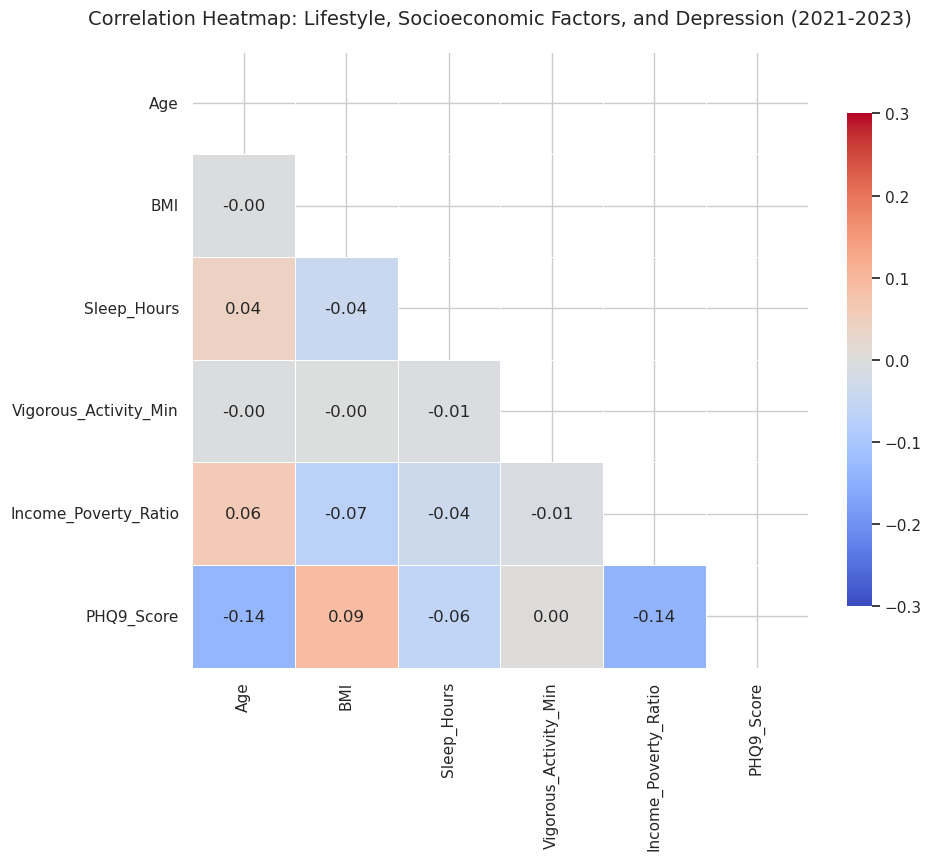

In [3]:
# --- Summary Statistics (5 generated) ---
print("--- EDA Summary Statistics ---\n")

# 1. Base rate of depression
dep_rate = df_clean['Depressed'].mean() * 100
print(f"1. Proportion of cohort screening positive for depression (PHQ9 >= 10): {dep_rate:.2f}%")

# 2. Median Activity
med_activity = df_clean['Vigorous_Activity_Min'].median()
print(f"2. Median vigorous physical activity (minutes/day) across cohort: {med_activity:.1f}")

# 3. Median Income Ratio
med_income = df_clean['Income_Poverty_Ratio'].median()
print(f"3. Median Income-to-Poverty Ratio (higher = greater financial stability): {med_income:.2f}")

# 4 & 5. Grouped statistic: Average Activity by Depression Status
activity_by_dep = df_clean.groupby('Depressed')['Vigorous_Activity_Min'].mean()
print(f"4. Average vigorous activity for NON-depressed individuals: {activity_by_dep[0]:.1f} mins/day")
print(f"5. Average vigorous activity for DEPRESSED individuals: {activity_by_dep[1]:.1f} mins/day\n")


# --- Graphic: Correlation Heatmap ---
plt.figure(figsize=(10, 8))

# Select only the continuous numerical variables for the heatmap
numeric_cols = ['Age', 'BMI', 'Sleep_Hours', 'Vigorous_Activity_Min', 'Income_Poverty_Ratio', 'PHQ9_Score']
corr_matrix = df_clean[numeric_cols].corr()

# Generate a mask for the upper triangle to make it easier to read
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=0.3, vmin=-0.3, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap: Lifestyle, Socioeconomic Factors, and Depression (2021-2023)', fontsize=14, pad=20)
plt.show()